# Name: Fereshteh Sadeghi Naieni Fard

# PART III: Build, Train, Test, and Evaluate ML Models

## 1. Load data

#### 1.1. Import Essential Libraries and Modules

In [124]:
#Import python libraries: Numpy and Pandas
import pandas as pd
import numpy as np

#Import libraries and modules of data visualization
from pandas.plotting import scatter_matrix
from matplotlib import pyplot

#Import scikit learn module to split the dataset into tarin and test sets
from sklearn.model_selection import train_test_split

#Import scikit learn module for the Linear regression model 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

#Import scikit learn module for k-fold cross validation, model evaluation and validation
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score


#### 1.2. Load the Dataset

#### The dataset abalone.csv has the following attributes:  
1.Sex   
2.Length: mm: Longest shell measurement   
3.Diameter: mm : perpendicular to the length  
4.Height : mm : with meat in the shell  
5.Whole weight : grams : whole abalone  
6.Shucked weight : grams : weight of meat  
7.Viscera weight : grams : gut weight (after bleeding)  
8.Shell weight : grams : after being dried  
9.Rings : integer : +1.5 gives the age in years  

In [125]:
# Specify the path of the dataset
filename='C:/unt courses/Ph.D courses/INFO-ADTA 5340-Discovery and Learning with Big Data/Week8 Final Project/abalone.csv'

#Specify the fields of the dataset
names=['Sex','Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings']

#Load the dataset and insert into a data
df=pd.read_csv(filename,names=names, index_col= False)

## 2. Preprocess the Dataset

In [126]:
#Calculate age field using rings+1.5
df['Age']=df['Rings']+1.5

In [127]:
#Drop the rings field as we dont need it more
df=df.drop(columns=['Rings'])

In [128]:
# Put null values for all zero values
df=df.replace(0,np.nan)

In [129]:
#Remove null records from the dataset
df=df.dropna()

In [130]:
#print all null values
print(df.isnull().sum())

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Age               0
dtype: int64


In [156]:
df.to_csv('C:/unt courses/Ph.D courses/INFO-ADTA 5340-Discovery and Learning with Big Data/Week8 Final Project/abalone_clean.csv',index=False)

## 3. Perform Exploratory Data Analysis

In [132]:
#Get the dimensions or shape of the dataset
print(df.shape)

(4175, 9)


In [133]:
#Get the data types of all the attributes
print(df.dtypes)

Sex                object
Length            float64
Diameter          float64
Height            float64
Whole weight      float64
Shucked weight    float64
Viscera weight    float64
Shell weight      float64
Age               float64
dtype: object


In [134]:
#Get the data types of all the varaibles of the dataset
print(df.head(5))

  Sex  Length  Diameter  Height  Whole weight  Shucked weight  Viscera weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell weight   Age  
0         0.150  16.5  
1         0.070   8.5  
2         0.210  10.5  
3         0.155  11.5  
4         0.055   8.5  


In [135]:
#Class distribution
#Means how many records for each class 
print(df.groupby('Sex').size())

Sex
F    1307
I    1340
M    1528
dtype: int64


In [136]:
#Get the summary statistics of the numeric variables of the dataset
print(df.describe())

            Length    Diameter       Height  Whole weight  Shucked weight  \
count  4175.000000  4175.00000  4175.000000   4175.000000     4175.000000   
mean      0.524065     0.40794     0.139583      0.829005        0.359476   
std       0.120069     0.09922     0.041725      0.490349        0.221954   
min       0.075000     0.05500     0.010000      0.002000        0.001000   
25%       0.450000     0.35000     0.115000      0.442250        0.186250   
50%       0.545000     0.42500     0.140000      0.800000        0.336000   
75%       0.615000     0.48000     0.165000      1.153500        0.502000   
max       0.815000     0.65000     1.130000      2.825500        1.488000   

       Viscera weight  Shell weight          Age  
count     4175.000000   4175.000000  4175.000000  
mean         0.180653      0.238834    11.435090  
std          0.109605      0.139212     3.224227  
min          0.000500      0.001500     2.500000  
25%          0.093500      0.130000     9.500000  


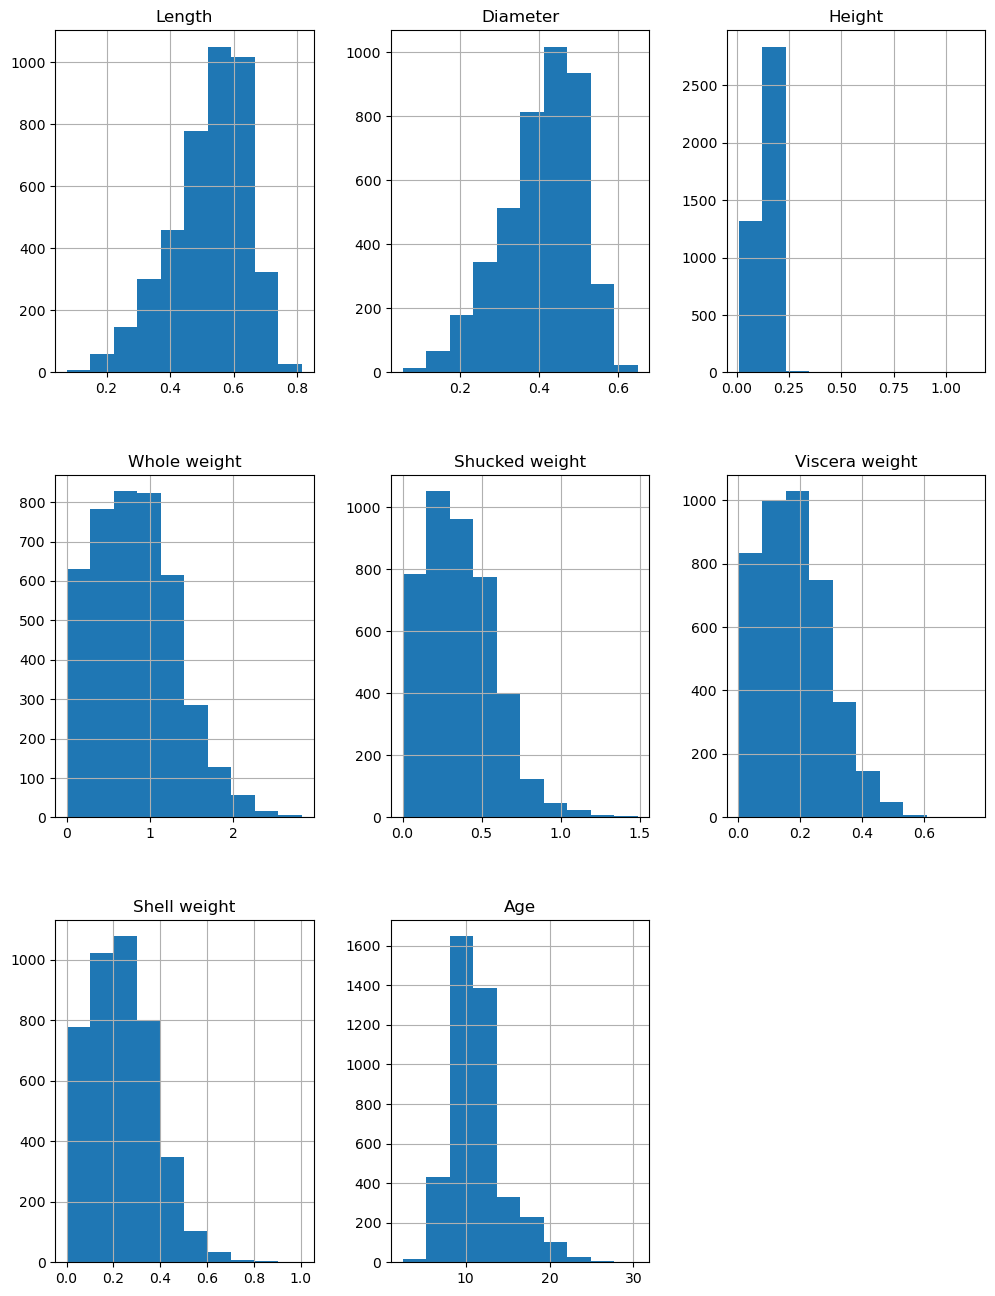

In [137]:
#Plot histogram for each numeric variable of the dataset
df.hist(figsize=(12,16))
pyplot.show()

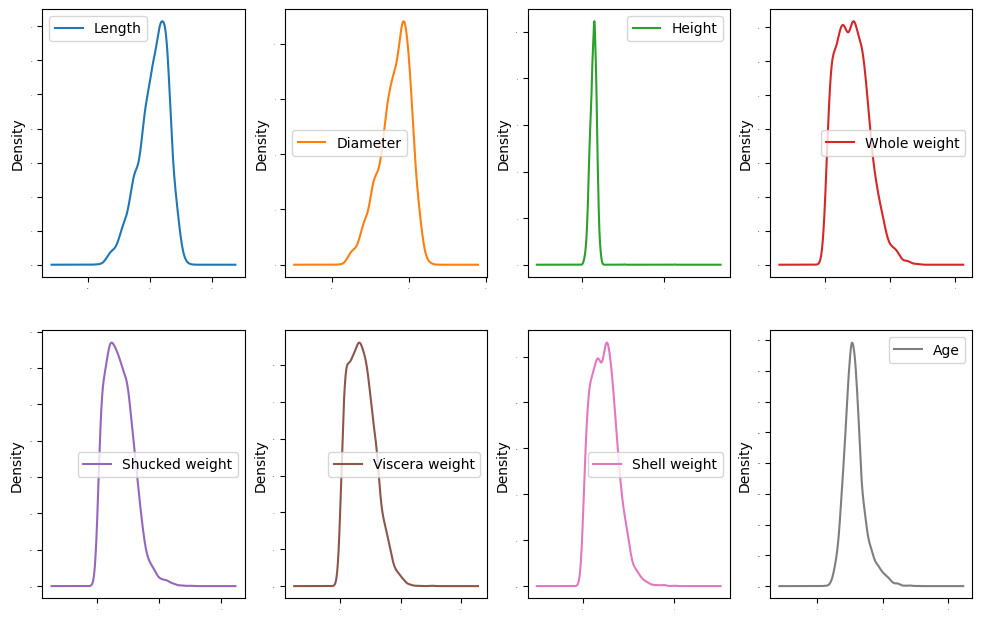

In [138]:
#Plot density plots for each numeric variable of the dataset
df.plot(kind='density', subplots=True, layout=(4,4),sharex=False, fontsize=1, figsize=(12,16))
pyplot.show()

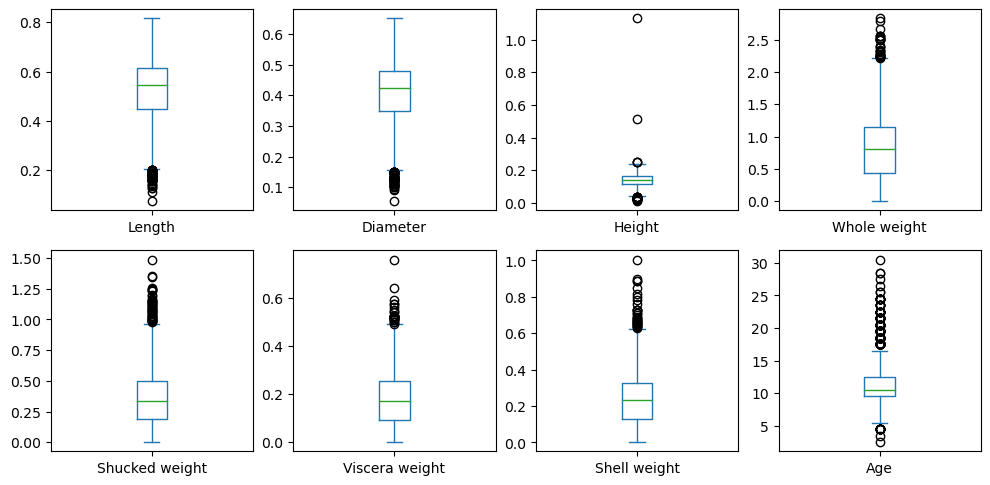

In [139]:
#Plot Boxplots for each numeric variable of the dataset
df.plot(kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False, legend=True, figsize=(12,12))
pyplot.show()

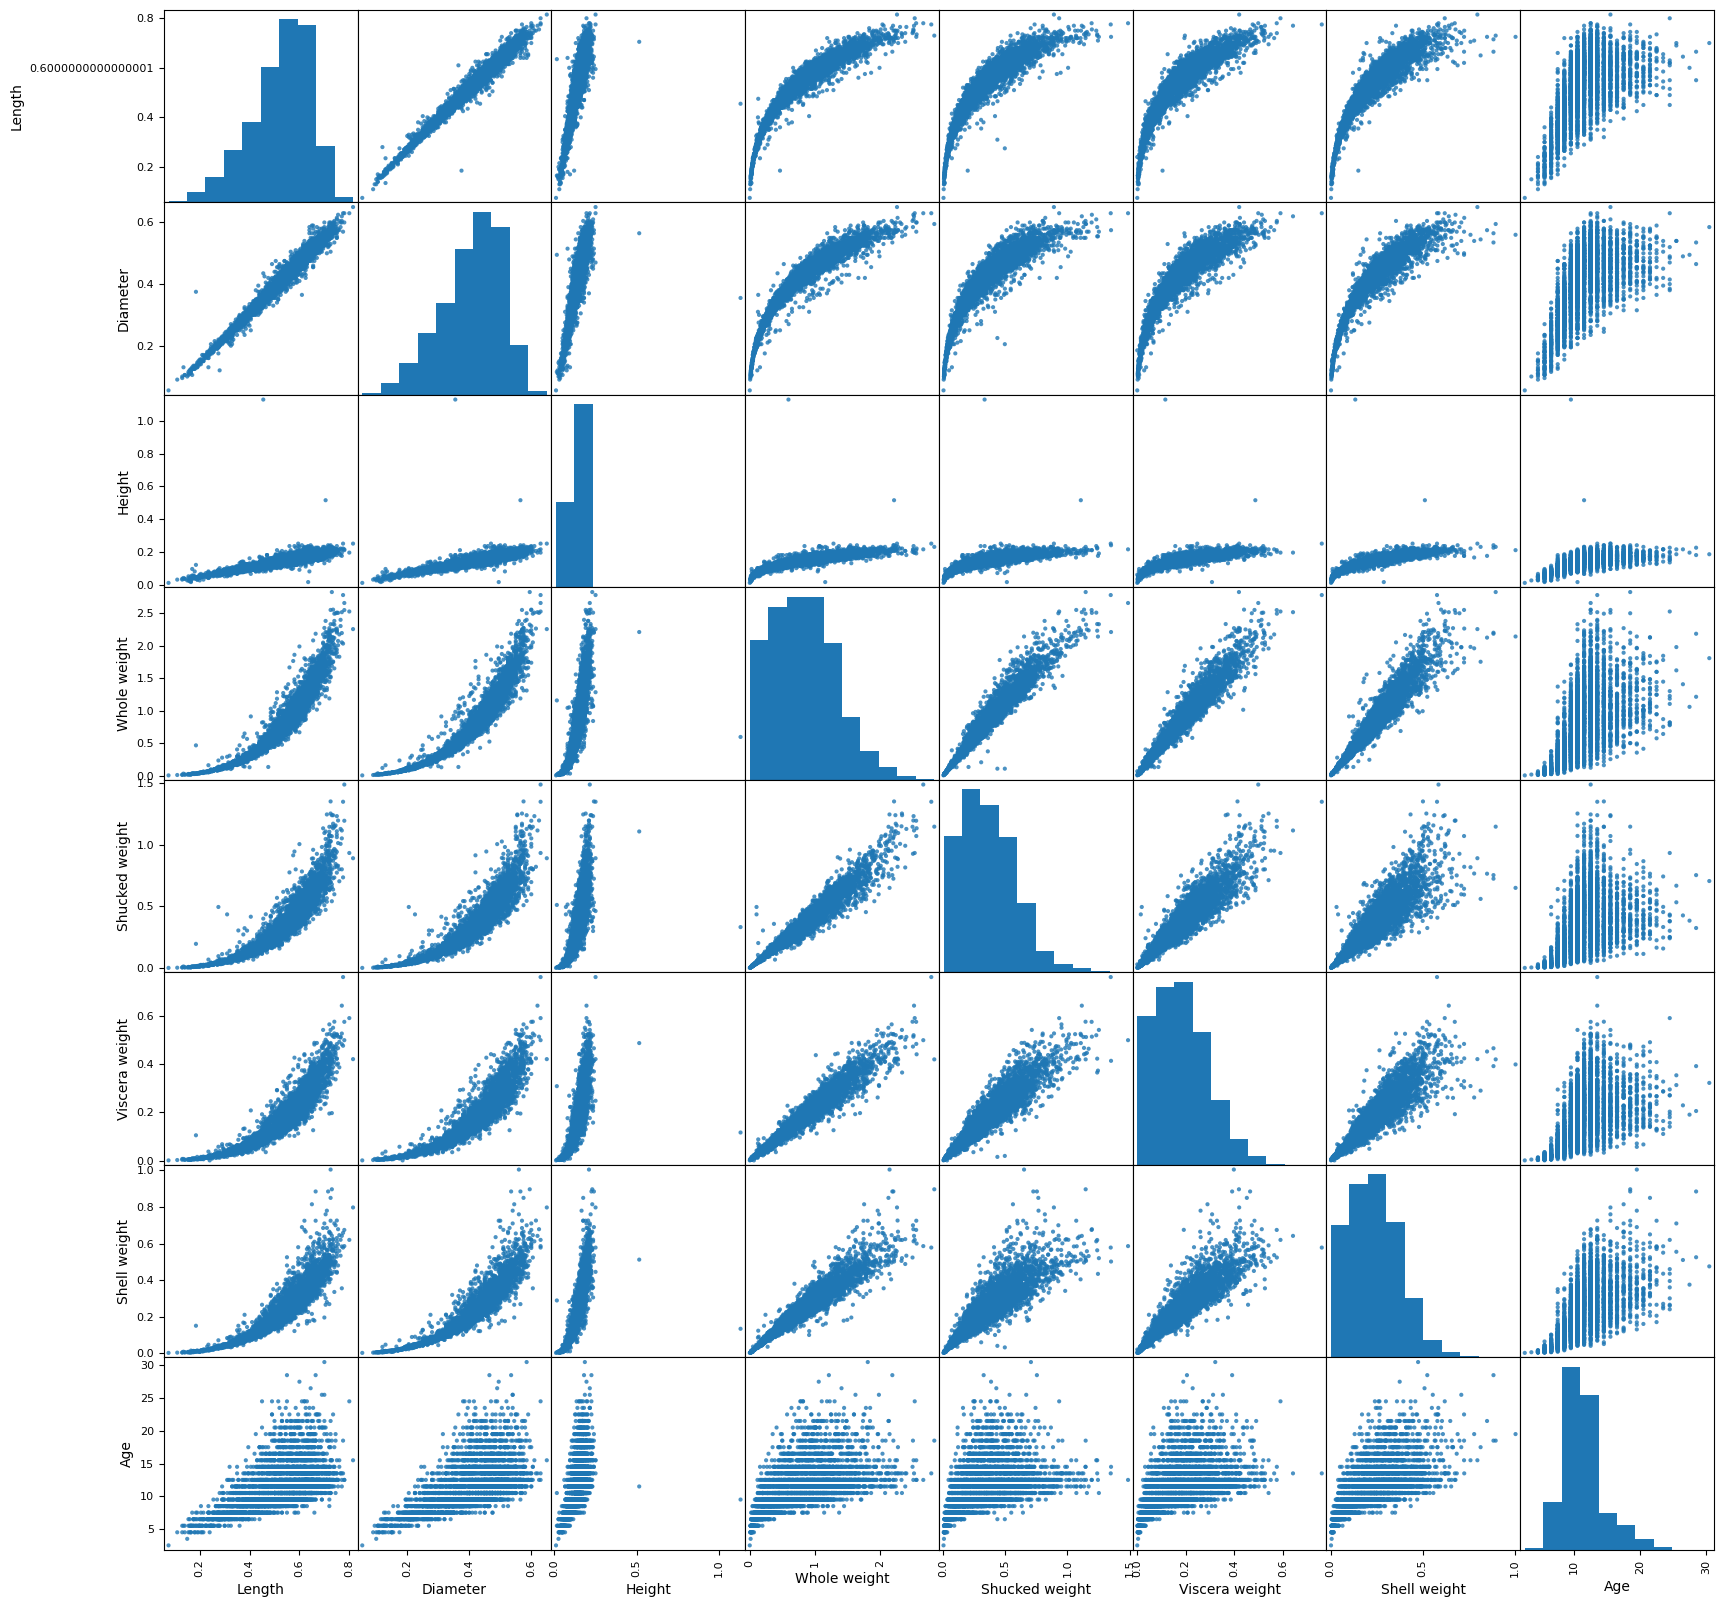

In [140]:
#Scatter plot matrix
scatter_matrix(df, alpha=0.8,figsize=(20,20))
pyplot.show()

## 4. Split the Dataset into Input and Output Arrays

In [141]:
#Convert category labels to numeric labales by setting the predefined orders
df['Sex'] = pd.Categorical(df['Sex'], categories=['M','F', 'I'], ordered=True)
df['Sex'] = df['Sex'].cat.codes   # 'M'=0,'F'=1, 'I'=2

In [142]:
#Store data values into a numpy array
array=df.values

#Seperate the dataset into two subdatasets to seperate it into predictors and tartget values
# Predictors or x array include all the columns except the last one
x=array[:,0:8]

# The last column include the target variable
y=array[:,8]

## 5. Split the Dataset into Train/Test Dataset

In [143]:
#Split dataset: Train set 67% of the data and test set 33 %
test_size=0.33

#Determine the seed for randomization
seed=7

#Split the dataset into train and test sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=test_size,random_state=seed)

## 5. Train the Machine Learning Model

In [144]:
#Build the model
model_LR=LinearRegression()

#Train the model
model_LR.fit(x_train,y_train)

#Print out the coefficients and intercept
print(model_LR.intercept_)
print(model_LR.coef_)

4.70768734436706
[ -0.36673588   1.37051095   7.16220355  24.25139694   9.28855114
 -20.47142308 -10.43903032   6.35937002]


In [145]:
# Build the model
model_DT=DecisionTreeRegressor()

#Train the model using train and test subdatasets
model_DT.fit(x_train, y_train)


DecisionTreeRegressor()

In [146]:
#Print out the list of coeffitients with their relevant variable names
#Pair the feature names with coeffitients
names_2=['Sex','Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings']
coeffs_zip=zip(names_2,model_LR.coef_)

#Convert iterator into set
coeffs=set(coeffs_zip)

#Print coeffs
for coef in coeffs:
    print(coef,"\n")

('Diameter', 7.162203546968227) 

('Length', 1.370510949462839) 

('Height', 24.251396944196646) 

('Viscera weight', -10.439030321392233) 

('Whole weight', 9.288551137480425) 

('Sex', -0.3667358763907175) 

('Shell weight', 6.359370022786769) 

('Shucked weight', -20.471423080415992) 



## 7. Calculate the R2 value

In [147]:
#Calsulate and print the R-square
R_square=model_LR.score(x_test,y_test)
print(R_square)

0.49220965327337185


In [148]:
# Calculate the r-squared 
Rsq=model_DT.score(x_test,y_test)
print(Rsq)

0.14596377485406142


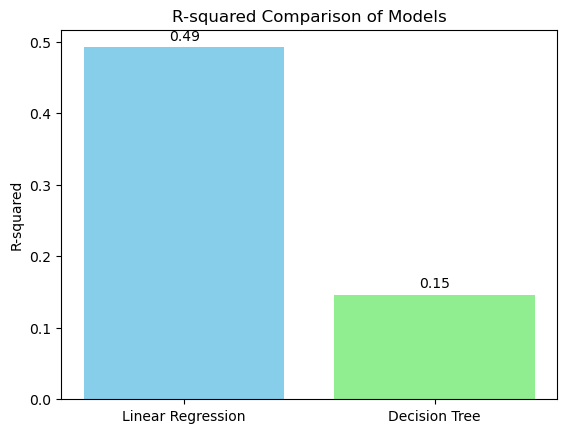

In [155]:
#Plot bar chart of the accuracies of the models
# R-squared values
r_values = [R_square, Rsq]
models = ["Linear Regression", "Decision Tree"]

# Create bar chart
pyplot.bar(models, r_values, color=['skyblue', 'lightgreen'])
pyplot.ylabel("R-squared")
pyplot.title("R-squared Comparison of Models")

# Show the value on top of each bar
for i, v in enumerate(r_values):
    pyplot.text(i, v + 0.01, f"{v:.2f}", ha='center')

pyplot.show()

## 6. Prediction

Sex: Male or 0  
Length: mm:0.54   
Diameter: mm :0.4   
Height : mm :0.15   
Whole weight :0.65   
Shucked weight : 0.2   
Viscera weight : 0.15   
Shell weight : 0.21   

In [121]:
model_LR.predict([[0,0.54,0.4,0.15,0.65,0.2,0.15,0.21]])

array([13.663241])

Sex: Female or 1   
Length: mm: 0.47   
Diameter: mm : 0.35   
Height : mm : 0.1  
Whole weight : 0.48  
Shucked weight : 0.17  
Viscera weight : 0.081  
Shell weight : 0.19  

In [149]:
model_LR.predict([[1,0.47,0.35,0.1,0.48,0.17,0.081,0.19]])

array([11.25808402])

## 7. Cross Validation

In [151]:
#Evaluate the algorithm
#Specify the K-size
num_folds=10

#Fix the random seed
seed=7

# Split the whole dataset into folds
kfold=KFold(n_splits=num_folds,  shuffle=True, random_state=seed)

#Use negative mean square error to evaluate the model or algorithm
scoring='neg_mean_squared_error'

#Train the model and then run kfold cross validation to validate and ebaluate the model
results=cross_val_score(model_LR,x,y,cv=kfold,scoring=scoring)

#Print out the evaluation results
#the average of all the results obtained from the kfold cross validation
print(results.mean())

-4.935986214850481
